In [1]:
################################################################################
# Install Project
################################################################################
import sys
import os
import importlib

if sys.version_info >= (3, 12):
    from types import ModuleType
    import types
    # Create a fake 'imp' module in memory
    m = types.ModuleType('imp')
    m.reload = importlib.reload
    sys.modules['imp'] = m

%load_ext autoreload
%autoreload 2

if os.path.isdir("variable_patchtst_project"):
    %cd variable_patchtst_project
    !git pull
    %cd ..
else:

    # Clone your repo
    !git clone https://github.com/Ethan-Russell/variable_patchtst_project.git

from variable_patchtst_project.src.variable_patchtst_project.models.patching import *

Cloning into 'variable_patchtst_project'...
remote: Enumerating objects: 125, done.
remote: Counting objects: 100% (125/125), done.
remote: Compressing objects: 100% (92/92), done.
remote: Total 125 (delta 39), reused 111 (delta 25), pack-reused 0 (from 0)
Receiving objects: 100% (125/125), 51.76 KiB | 1.44 MiB/s, done.
Resolving deltas: 100% (39/39), done.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_patch_segments(patch_defs, seq_len, title, save_path="patch_segments.pdf"):
    """
    Plots patches as individual line segments with dots at the endpoints.
    patch_defs: List of (start, end, patch_size)
    """

    plt.rcParams.update({
        "text.usetex": False,
        "font.family": "serif"
    })

    fig, ax = plt.subplots(figsize=(5, 4), dpi=300)

    # 2. Sort patches by size then start time for a structured look
    # We want the "Recent/Small" patches at the bottom and "Old/Large" at the top
    sorted_patches = sorted(patch_defs, key=lambda x: x[0], reverse=True)

    unique_sizes = sorted(list(set([p[2] for p in patch_defs])))
    colors = plt.cm.plasma(np.linspace(0.1, 0.8, 10))

    cmap = plt.get_cmap('tab10')

    size_to_color = {2**i: cmap((i-2)%10) for i in range(1+int(np.rint(np.log2(max(unique_sizes)))))}
    print(size_to_color)

    # size_to_color = {size: colors[i] for i, size in enumerate(unique_sizes)}



    # 3. Plot each segment
    for i, (start, end, p_size) in enumerate(sorted_patches):
        y = i  # Each patch gets its own row
        color = size_to_color[p_size]

        # Plot the horizontal line
        ax.hlines(y, start, end, colors=color, linewidth=2, alpha=0.8)

        # Plot dots at endpoints to show exact boundaries
        # ax.scatter([start, end], [y, y], color=color, s=15, zorder=3)

        # Optional: Label the size on the right side for the first of each group
        if i == 0 or sorted_patches[i-1][2] != p_size:
            ax.text(seq_len + 18, y+4, f"Size: {p_size}", va='center', fontsize=8, color=color, fontweight='bold')

    # 4. Formatting
    ax.set_xlabel("Time Index (Sequence Length)")
    ax.set_ylabel("Individual Patches (Stacked)")
    # ax.set_title(title, pad=15)

    # Set x-ticks to show the full context length
    ax.set_xlim(-5, seq_len + 15)
    ax.set_xticks(np.arange(0, seq_len +1, seq_len // 4))

    # Hide y-ticks since the individual index isn't as important as the visual density
    ax.set_yticks([])

    # Add a vertical line to show "Now"
    ax.axvline(x=seq_len, color='red', linestyle='--', alpha=0.5, label="Current Time (T)")

    # Grid and Spines
    ax.grid(axis='x', linestyle=':', alpha=0.4)
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines['left'].set_visible(True)

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()

{1: (np.float64(0.7372549019607844), np.float64(0.7411764705882353), np.float64(0.13333333333333333), np.float64(1.0)), 2: (np.float64(0.09019607843137255), np.float64(0.7450980392156863), np.float64(0.8117647058823529), np.float64(1.0)), 4: (np.float64(0.12156862745098039), np.float64(0.4666666666666667), np.float64(0.7058823529411765), np.float64(1.0)), 8: (np.float64(1.0), np.float64(0.4980392156862745), np.float64(0.054901960784313725), np.float64(1.0)), 16: (np.float64(0.17254901960784313), np.float64(0.6274509803921569), np.float64(0.17254901960784313), np.float64(1.0)), 32: (np.float64(0.8392156862745098), np.float64(0.15294117647058825), np.float64(0.1568627450980392), np.float64(1.0))}


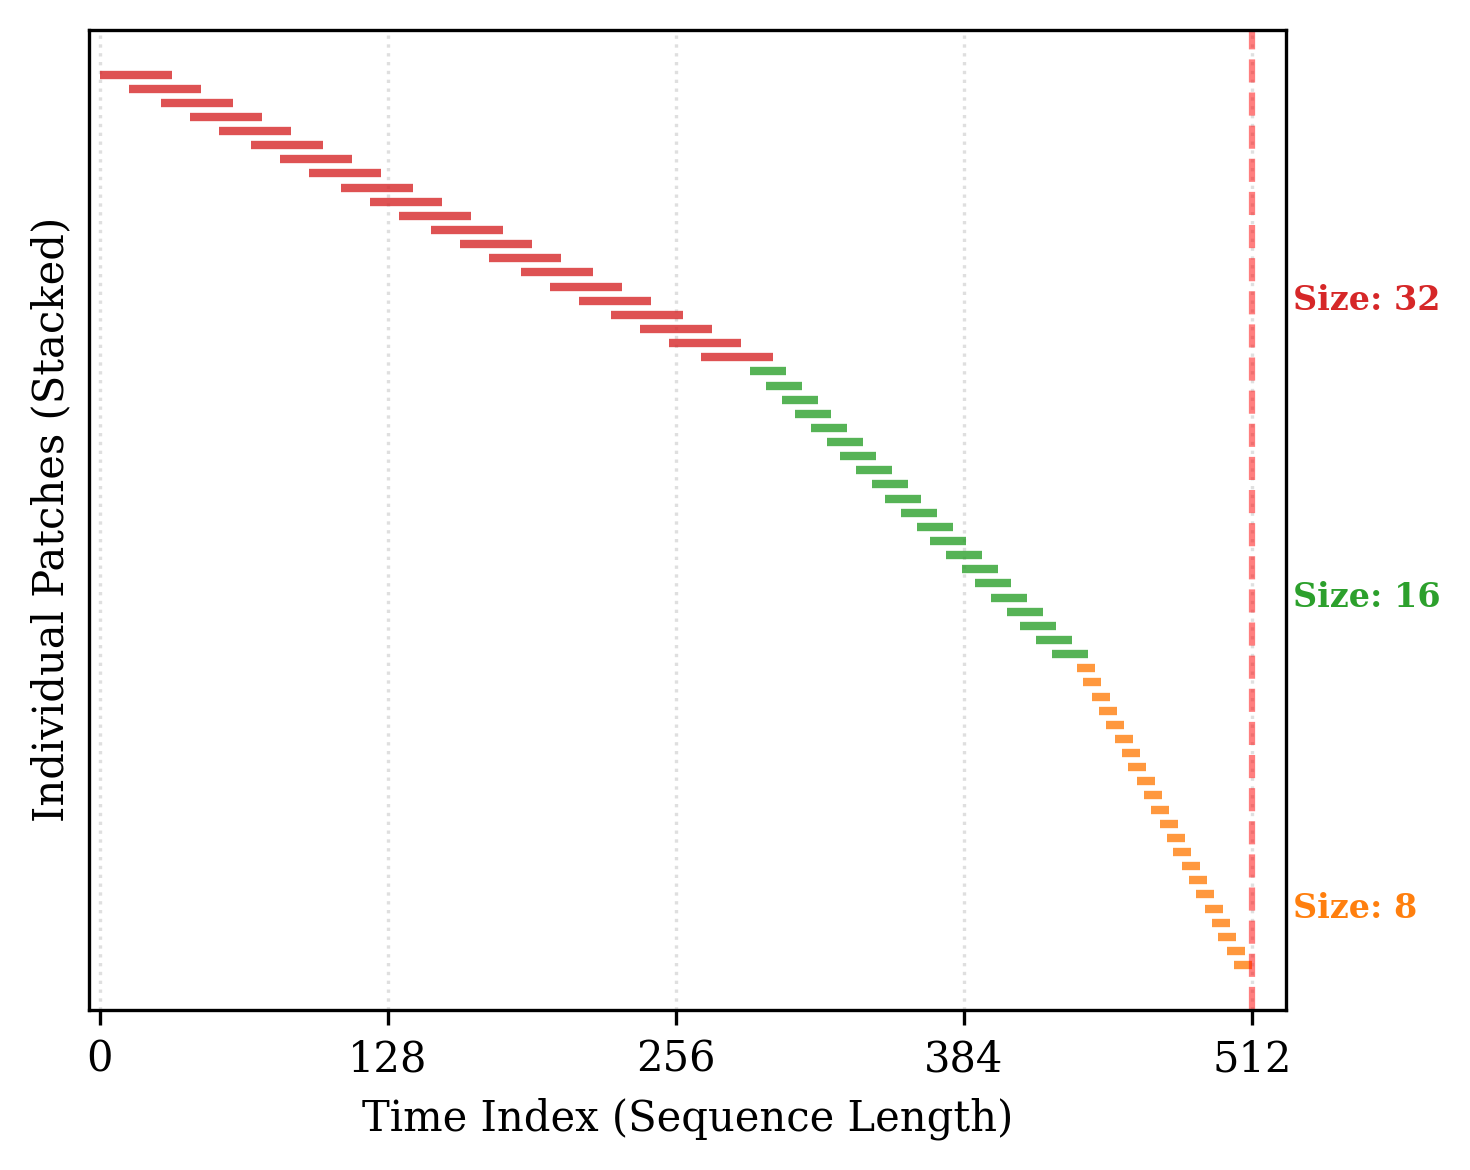

{1: (np.float64(0.7372549019607844), np.float64(0.7411764705882353), np.float64(0.13333333333333333), np.float64(1.0)), 2: (np.float64(0.09019607843137255), np.float64(0.7450980392156863), np.float64(0.8117647058823529), np.float64(1.0)), 4: (np.float64(0.12156862745098039), np.float64(0.4666666666666667), np.float64(0.7058823529411765), np.float64(1.0)), 8: (np.float64(1.0), np.float64(0.4980392156862745), np.float64(0.054901960784313725), np.float64(1.0)), 16: (np.float64(0.17254901960784313), np.float64(0.6274509803921569), np.float64(0.17254901960784313), np.float64(1.0))}


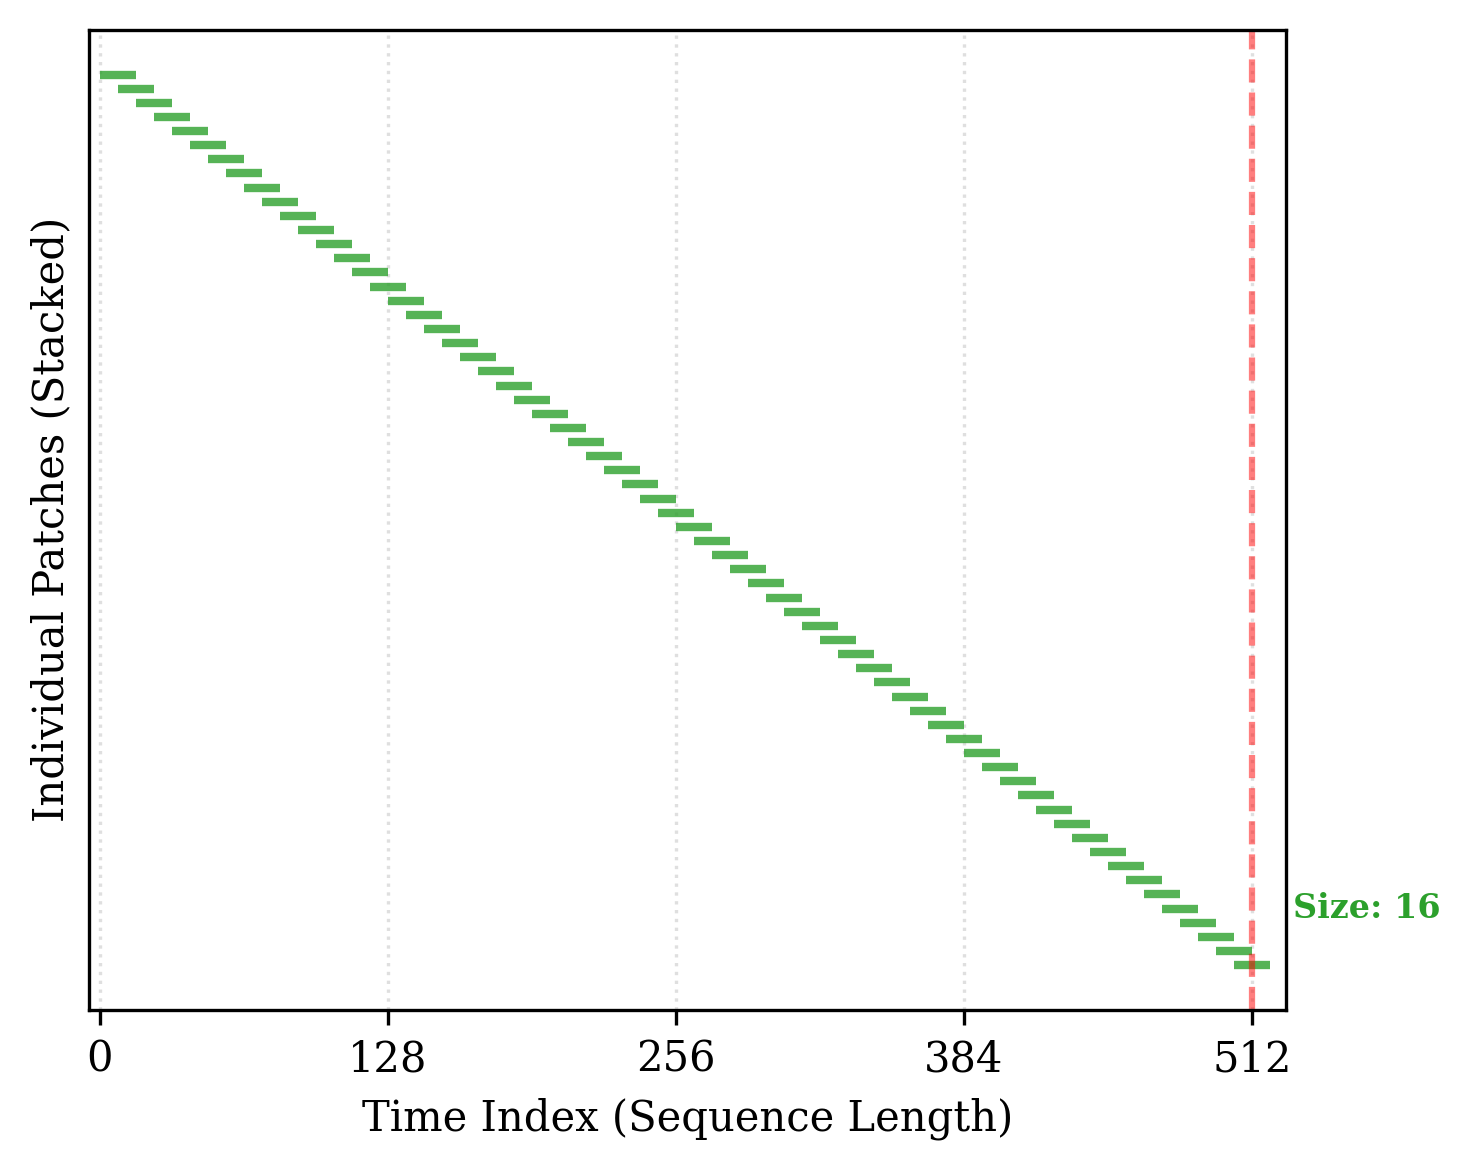

In [12]:
seq_len = 512
num_patches = 64
min_patch_size = 8
num_scales = 3
plot_patch_segments(
    patch_defs = get_perfect_patches(
        seq_len,
        num_patches,
        min_patch_size,
        num_scales
    ),
    seq_len = seq_len,
    title = "Variable Patch Coverage",
    save_path = "variable_patches.pdf"
)


patch_length = 16
stride = 8
plot_patch_segments(
    patch_defs = get_uniform_patches(seq_len, patch_length, stride),
    seq_len = seq_len,
    title = "Uniform Patch Coverage",
    save_path = "uniform_patches.pdf"
)